# Which measurements moved

A hit call says a perturbation moved, and a mechanism call says what it resembles. Neither says what changed in
the cell. This page tests features against the controls, collapses them into families a biologist can read,
and lends names to the axes of an embedding, which has none of its own.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

import scanpy as sc

import mantispy as mt

## Test the unit that was randomized

A well of a few hundred cells is not a few hundred independent observations of a treatment. The cells share the
well's confluency, focus and plate position. Single-cell transcriptomics settled on pseudobulk for this: aggregate
to the unit that was randomized, then test.

The cost of ignoring this can be measured on wells where nothing differs. Take the eight DMSO wells of the JUMP
plate in {func}`~mantispy.ds.jump_cells`, split them into two halves of four, and test the halves against each
other, once cell by cell and once on the well medians. Every feature called is a false positive by construction.

In [2]:
from mantispy._core._stats import benjamini_hochberg

cells = mt.ds.jump_cells(selected=True)
mt.pp.normalize(cells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
controls = cells[cells.obs["Metadata_Control"].to_numpy()].copy()

values = np.asarray(controls.X, dtype=float)
values = values[:, np.isfinite(values).all(axis=0)]
well = controls.obs["Metadata_Well"].astype(str).to_numpy()
names = sorted(set(well))
left = np.isin(well, names[::2])

_, per_cell = stats.mannwhitneyu(values[left], values[~left], axis=0)
medians = pd.DataFrame(values).groupby(well).median()
on_left = medians.index.isin(names[::2])
_, per_well = stats.ttest_ind(medians[on_left], medians[~on_left], axis=0)

{
    "control wells": len(names),
    "cells": len(well),
    "features": values.shape[1],
    "called at q < 0.05, cell by cell": int((benjamini_hochberg(per_cell) < 0.05).sum()),
    "called at q < 0.05, on well medians": int((benjamini_hochberg(per_well) < 0.05).sum()),
}

{'control wells': 8,
 'cells': 5421,
 'features': 1598,
 'called at q < 0.05, cell by cell': 677,
 'called at q < 0.05, on well medians': 0}

Cell by cell, 677 of 1,598 features differ between two halves of the DMSO wells, where nothing differs. On the
well medians, none do. The cells of a well share its confluency, focus and position, so a per-cell test counts a few
hundred correlated observations as independent evidence.

For this reason `tl.differential_features` rejects cell-resolution input and points to `tl.aggregate`. The same
applies to `tl.rank_features`, which does run per cell: it is the right tool only when the cells themselves are the
population you are describing, not when they are replicates of a treatment.

In [3]:
try:
    mt.tl.differential_features(cells)
except ValueError as error:
    print(error)

differential_features needs well-level profiles; testing per cell treats cells as independent replicates and inflates the false discovery rate. Aggregate first with adata = mt.tl.aggregate(adata).


<path>:2: UserWarning: this function expects 'well' or 'perturbation' resolution but the object is annotated 'cell'; results may not mean what you expect
  mt.tl.differential_features(cells)


## The p-value floor of a rank test

{func}`~mantispy.tl.effect_size` computes a Mann-Whitney p-value per feature and group. A rank test's
resolution is limited by the number of observations: with few treated wells there are only so many ways to
interleave them with the controls, so there is a smallest p-value it can produce, however large the effect.
The treated values below all lie above every control, the largest effect the test can see.

In [4]:
control = np.arange(300, dtype=float)
floor = pd.DataFrame(
    [
        {
            "treated wells": n,
            # Distinct values, not np.full: identical treated wells tie with each other,
            # and scipy answers a tied sample with the normal approximation instead of the
            # exact null, which gives a different, much larger number.
            "smallest possible p": stats.mannwhitneyu(np.arange(n, dtype=float) + 1e6, control).pvalue,
        }
        for n in (2, 3, 4, 6, 8)
    ]
)
floor["smallest possible p"] = floor["smallest possible p"].map("{:.2e}".format)
floor

,treated wells,smallest possible p
0,2,4.40e-05
1,3,4.36e-07
2,4,5.73e-09
3,6,1.84e-12
4,8,1.09e-15


A screen testing a few hundred genes across a few hundred features runs on the order of 10⁵ tests, so the
top-ranked test needs a p-value of about 5e-07 to survive multiple-testing correction. At two wells the floor
is a hundred times too large, so no effect of any size can be called. At three it is the same order as the
threshold, and at four it no longer limits anything.

{func}`~mantispy.tl.differential_features` fits a moderated t-test instead, with wells as the replicates, and
has no such floor. {func}`~mantispy.metrics.diagnose_testing` checks both on your own screen: the rank test's
resolution against the number of tests, and whether the parametric p-values are calibrated, by relabelling
control wells as pseudo-treatments.

## On a real screen

rohban is an ORF overexpression screen: one gene per well, about ten replicate wells per gene over five plates.
Its untransfected wells are neither a gene nor a control, so they go first.

In [5]:
adata = mt.ds.rohban()
adata = adata[adata.obs["Metadata_gene_name"] != "EMPTY"].copy()
mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(adata, na_cutoff=0.0)
adata = mt.pp.subset_features(adata)

mt.metrics.diagnose_testing(adata)

<path>:3: UserWarning: 65 of 3616 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")


,check,value,expected,verdict,note
0,wells per treatment,10 (min 4),>= 3,pass,"the unit that was randomized, and the sample s..."
1,treatments sharing a Metadata_Plate with the r...,190 of 190,all,pass,median 5 Metadata_Plate per treatment
2,excess kurtosis,44.0,0 (Gaussian),warn,heavy tails break the small p-values first; mt...
3,rank test resolution,1.6e-07,< 3.4e-07,pass,smallest p a Mann-Whitney can return with 10 w...
4,null p < 0.05,7.4%,5%,pass,"control wells relabeled as 10-well treatments,..."
5,null p < 0.01,3.1%,1%,FAIL,"control wells relabeled as 10-well treatments,..."
6,null discoveries,"1 of 6,128",0,FAIL,findings on data where there is nothing to find
7,hit_calling null rate,1 of 8,<= 2,pass,hit_calling called a control-only pseudo-treat...
8,edistance null rate,2 of 8,<= 2,pass,edistance called a control-only pseudo-treatme...


At ten wells per gene the rank test has all the resolution it needs. The parametric test's tail does not hold:
control wells relabelled as ten-well treatments fall below p = 0.01 three times as often as they should, and a
false discovery survives the correction on data where there is nothing to find. The features are heavy-tailed,
with an excess kurtosis of 44 where a Gaussian has none. Rank-transform them and check again:

In [6]:
mt.pp.rank_int(adata)
mt.metrics.diagnose_testing(adata)

,check,value,expected,verdict,note
0,wells per treatment,10 (min 4),>= 3,pass,"the unit that was randomized, and the sample s..."
1,treatments sharing a Metadata_Plate with the r...,190 of 190,all,pass,median 5 Metadata_Plate per treatment
2,excess kurtosis,-0.0,0 (Gaussian),pass,heavy tails break the small p-values first; mt...
3,rank test resolution,1.6e-07,< 3.4e-07,pass,smallest p a Mann-Whitney can return with 10 w...
4,null p < 0.05,5.5%,5%,pass,"control wells relabeled as 10-well treatments,..."
5,null p < 0.01,0.9%,1%,pass,"control wells relabeled as 10-well treatments,..."
6,null discoveries,"0 of 6,128",0,pass,findings on data where there is nothing to find
7,hit_calling null rate,0 of 8,<= 2,pass,hit_calling called a control-only pseudo-treat...
8,edistance null rate,0 of 8,<= 2,pass,edistance called a control-only pseudo-treatme...


After {func}`~mantispy.pp.rank_int` every check passes: 0.9% of the null falls below p = 0.01 and nothing is
discovered on it. The transform is also a step of the consortium's compound recipe.

In [7]:
mt.tl.differential_features(adata, block="Metadata_Plate")
table = adata.uns["mantispy"]["differential"]
called = table[table["qvalue"] < 0.05]
print(
    f"{len(called)} of {len(table)} tests called at q < 0.05, in {called['group'].nunique()} of {table['group'].nunique()} genes"
)
called.sort_values("qvalue").head(8)

33793 of 145540 tests called at q < 0.05, in 189 of 190 genes


,group,feature,difference,t,pvalue,qvalue
109128,RAF1,Cytoplasm_Intensity_LowerQuartileIntensity_RNA,2.766217,12.549329,1.337704e-26,1.946894e-21
108973,RAF1,Cells_RadialDistribution_RadialCV_RNA_3of4,-2.380923,-12.394384,3.866567e-26,2.813701e-21
27808,CEBPA,Cells_Texture_InfoMeas1_ER_5_02_256,3.175778,11.954069,9.625190e-25,4.669500e-20
27604,CEBPA,Cells_Correlation_Correlation_AGP_DNA,-3.079383,-11.892230,1.463139e-24,5.323631e-20
18740,BRAF,Cytoplasm_Intensity_LowerQuartileIntensity_RNA,2.622494,11.707125,4.452446e-24,8.100112e-20
49370,ERG,Cytoplasm_Granularity_8_DNA,3.107021,11.784207,3.488408e-24,8.100112e-20
108806,RAF1,Cells_Correlation_Correlation_DNA_RNA,-2.544252,-11.703200,4.330589e-24,8.100112e-20
66833,JUN,Cells_RadialDistribution_RadialCV_DNA_4of4,2.875414,11.777718,3.451884e-24,8.100112e-20


Nearly every gene moves some features: with ten wells per gene the test has the power to call small, consistent
shifts. The top of the table already reads as biology. RAF1 and BRAF, two kinases of the same MAPK cascade, both
raise the same feature, the lower quartile of cytoplasmic RNA intensity. A table of tens of thousands of calls
says that a lot changed, not what; the next sections read it by family.

## What blocking on plate does

`differential_features` takes `block=`, which adds the plate to the model as a fixed effect. On data that was
not normalized per plate it recovers the power plate variance would cost. It also refuses a confounded layout:
if a perturbation's wells sit only on plates without control wells, its treatment and its plate are the same
variable and no test can separate them.

BBBC021 shows what that looks like, and the rest of this page uses the screen, because its mechanisms give the
signatures below something to be read against. Lactacystin at 10 uM sits on three plates, which hold 18 DMSO
wells between them.

In [8]:
bbbc = mt.ds.bbbc021()
mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(bbbc, na_cutoff=0.0)
bbbc = mt.pp.subset_features(bbbc)

lactacystin = (bbbc.obs["Metadata_Perturbation"] == "lactacystin@10.0").to_numpy()
plates = set(bbbc.obs.loc[lactacystin, "Metadata_Plate"])
{
    "lactacystin@10.0 wells": int(lactacystin.sum()),
    "on plates": sorted(plates),
    "DMSO wells on those plates": int((bbbc.obs["Metadata_Control"] & bbbc.obs["Metadata_Plate"].isin(plates)).sum()),
}

<path>:2: UserWarning: 2 of 467 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")


{'lactacystin@10.0 wells': 3,
 'on plates': ['Week6_31641', 'Week6_31661', 'Week6_31681'],
 'DMSO wells on those plates': 18}

In [9]:
# Had QC dropped the DMSO wells of those three plates, lactacystin's plates would hold no controls.
lost = bbbc.obs["Metadata_Control"].to_numpy() & bbbc.obs["Metadata_Plate"].isin(plates).to_numpy()
confounded = bbbc[(lactacystin | bbbc.obs["Metadata_Control"].to_numpy()) & ~lost].copy()
mt.tl.differential_features(confounded, block=None, key_added="unblocked")
unblocked = confounded.uns["mantispy"]["unblocked"]
print(f"unblocked: {(unblocked['qvalue'] < 0.05).sum()} of {len(unblocked)} features called")

try:
    mt.tl.differential_features(confounded, block="Metadata_Plate")
except ValueError as error:
    print(f"blocked:   {error}")

unblocked: 77 of 343 features called
blocked:   no group had enough replicates in blocks shared with the reference


With the DMSO wells of lactacystin's three plates removed, the unblocked test calls 77 of 343 features, and any of
them could be the plate. Blocked on plate, the test refuses, because no lactacystin well then shares a plate with a
control.

## From features to feature families

A differential table has one row per (perturbation, feature), and a screen has thousands of
features, so the table does not directly say what a compound did. Biologists read results at
the level of feature families, such as intensity in the tubulin channel or texture in the
nucleus. `tl.feature_signature` collapses the table into families and keeps the sign.

In [10]:
mt.tl.differential_features(bbbc, key_added="vs_dmso")
signature = mt.tl.feature_signature(bbbc, key="vs_dmso")
signature

AnnData object with n_obs × n_vars = 103 × 19
    obs: 'Metadata_Perturbation', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control'
    var: 'feature_group', 'channel', 'object', 'n_features'
    uns: 'mantispy'
    layers: None (.X)

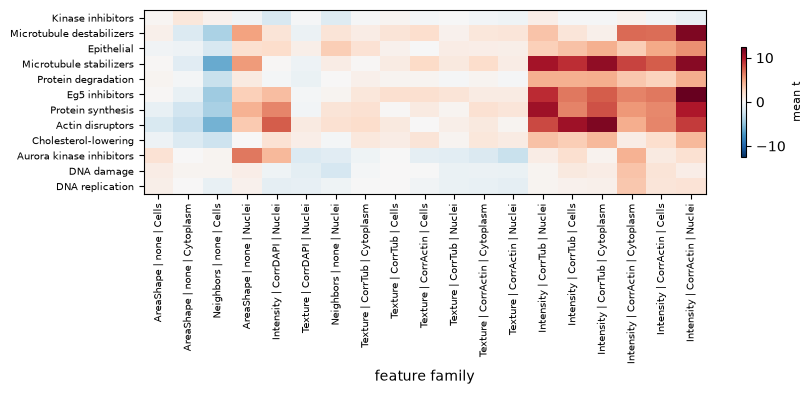

In [11]:
ax = mt.pl.feature_signature(signature, groupby="Metadata_MOA")
plt.show()

In [12]:
families = mt.get.to_dataframe(signature, metadata=False).astype(float)
by_mechanism = families.groupby(signature.obs["Metadata_MOA"].astype(str).to_numpy()).mean()
mechanisms = ("Microtubule stabilizers", "Microtubule destabilizers", "Eg5 inhibitors", "Actin disruptors")
{mechanism: by_mechanism.loc[mechanism].nlargest(2).round(1).to_dict() for mechanism in mechanisms}

{'Microtubule stabilizers': {'Intensity | CorrActin | Nuclei': 11.4,
  'Intensity | CorrTub | Cytoplasm': 11.1},
 'Microtubule destabilizers': {'Intensity | CorrActin | Nuclei': 11.6,
  'Intensity | CorrActin | Cytoplasm': 7.0},
 'Eg5 inhibitors': {'Intensity | CorrActin | Nuclei': 12.5,
  'Intensity | CorrTub | Nuclei': 9.3},
 'Actin disruptors': {'Intensity | CorrTub | Cytoplasm': 11.6,
  'Intensity | CorrTub | Cells': 10.6}}

Compare the rows with what each stain shows. The mechanisms move the cytoskeleton channels, and not always the
one their target sits in. Actin intensity over the nucleus is the largest change for microtubule
destabilizers and Eg5 inhibitors, and about level with tubulin intensity in the cytoplasm for microtubule
stabilizers, while the actin disruptors change tubulin intensity most. The two cytoskeletons are mechanically
coupled, and a cell arrested in mitosis rounds up over its nucleus.

So look at the signature instead of assuming it. A drug that targets X does not necessarily cause its largest
measured change in channel X.

The other contrast, `contrast="rest"`, tests each treatment against every other one rather than against the
controls. That subtracts what a treatment shares with all the others, including the ones with
the same mechanism, so it makes a single treatment distinctive and blurs its mechanism group. Use
`contrast="rest"` to tell perturbations apart and `contrast="reference"`, as in the figure, to find which ones
belong together.

{func}`~mantispy.tl.enrich` scores the same families on consensus profiles with decoupler, as the
[overview](../overview.ipynb) does.

## When the features have no names

The hardest thing about an embedding is that a result has no vocabulary. A CellProfiler hit comes with
"nuclear texture went down"; an embedding hit comes with a compound ID and nothing else.

[JUMP-Lite](../../datasets/jump_lite.ipynb) lets you fix that cleanly, because the same wells were measured both ways. Use
the named block to name the unnamed one: regress every CellProfiler measurement on the embedding's
components and ask how much of it the embedding already carries.

One thing to get right first. `ds.jump_lite` returns the six blocks in one row order, but the files it reads
list the wells in six different orders, and so will most tables from different pipelines. **Stacking two
blocks positionally is then silent and wrong, so align on the index.**

In [13]:
def embedded(model):
    """One JUMP-Lite embedding, normalized per plate and reduced to its first 50 components."""
    wells = mt.ds.jump_lite(model)
    mt.pp.normalize(wells, method="mad_robustize", by="Metadata_Plate", reference="negcon")
    mt.pp.feature_select(wells, operations=("drop_degenerate", "drop_na_columns"), na_cutoff=0.0)
    wells = mt.pp.subset_features(wells)
    sc.pp.pca(wells, n_comps=50)
    return wells


blocks = {model: embedded(model) for model in ("openphenom", "dinov2", "dinov2_random")}

In [14]:
embedding = blocks["openphenom"]

# The question is how much of each named measurement the embedding carries, so keep them all and drop only
# the runaway ones.
named = mt.ds.jump_lite("cp_measure")
mt.pp.normalize(named, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(named, operations=("drop_degenerate", "drop_na_columns", "drop_outliers"), na_cutoff=0.0)
named = mt.pp.subset_features(named)

aligned = named[named.obs_names.get_indexer(embedding.obs_names)].copy()
{
    "named measurements kept": named.n_vars,
    "same set of wells": set(embedding.obs_names) == set(named.obs_names),
    "rows out of OpenPhenom's order, per block": {
        model: int((wells.obs_names != embedding.obs_names).sum()) for model, wells in blocks.items()
    },
}

<path>:6: UserWarning: 30 of 2550 features have no reference values to centre on in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon', because every value there is missing or infinite. Their centre is set to 0 where it is missing and their scale to 1, so the values measured outside the reference rows pass through unnormalized instead of becoming NaN, and are not comparable across groups. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy().
  mt.pp.normalize(named, method="mad_robustize", by="Metadata_Plate", reference="negcon")
<path>:6: UserWarning: 103 of 2550 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_

{'named measurements kept': 1857,
 'same set of wells': True,
 "rows out of OpenPhenom's order, per block": {'openphenom': 0,
  'dinov2': 0,
  'dinov2_random': 0}}

In [15]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold


def standard(block):
    """Centre and scale each column, leaving a column that never varies alone rather than dividing by zero."""
    spread = block.std(0)
    return (block - block.mean(0)) / np.where(spread > 0, spread, 1)


measurements = standard(np.asarray(aligned.X, dtype=float))


def carried(wells):
    """Out-of-fold R^2 of every CellProfiler measurement, predicted from this block's components."""
    # Put each block into the order `aligned` is in rather than trusting the two to match. When they do not,
    # skipping this is silent: the regression simply finds nothing, and an informative block scores like a random one.
    X = np.asarray(wells[wells.obs_names.get_indexer(aligned.obs_names)].obsm["X_pca"], dtype=float)
    Y = measurements

    predicted = np.zeros_like(Y)
    for train, test in KFold(5, shuffle=True, random_state=0).split(X):
        predicted[test] = RidgeCV(alphas=np.logspace(-1, 4, 12)).fit(X[train], Y[train]).predict(X[test])
    return pd.Series(1 - ((Y - predicted) ** 2).sum(0) / (Y**2).sum(0), index=aligned.var_names)


explained = pd.DataFrame({name: carried(blocks[name]) for name in ("openphenom", "dinov2", "dinov2_random")})
explained["feature_group"] = aligned.var["feature_group"].to_numpy()
explained["object"] = aligned.var["object"].to_numpy()

by_group = explained.groupby("feature_group", observed=True)[["openphenom", "dinov2", "dinov2_random"]].median()
by_group.sort_values("openphenom", ascending=False).round(3)

,openphenom,dinov2,dinov2_random
feature_group,,,
texture,0.816,0.747,0.235
ferret,0.637,0.683,0.160
intensity,0.617,0.594,0.152
radial_distribution,0.551,0.542,0.179
radial_zernikes,0.491,0.522,0.152
sizeshape,0.484,0.592,0.010
zernike,0.472,0.516,0.152


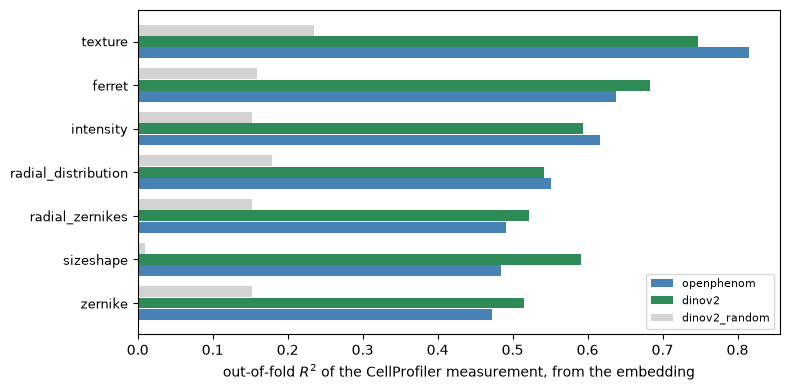

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
panel = by_group.sort_values("openphenom")
positions = np.arange(len(panel))
for offset, name, colour in (
    (-0.26, "openphenom", "steelblue"),
    (0.0, "dinov2", "seagreen"),
    (0.26, "dinov2_random", "lightgrey"),
):
    ax.barh(positions + offset, panel[name], 0.25, label=name, color=colour)
ax.set_yticks(positions, panel.index, fontsize=9)
ax.set_xlabel("out-of-fold $R^2$ of the CellProfiler measurement, from the embedding")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

That is a vocabulary for the embedding, and it is specific enough to act on. Both trained models reconstruct
the *texture* measurements best, and the untrained model reconstructs little of anything — the gap between the
grey bars and the coloured ones is what training bought, measured in units a CellProfiler user already
understands.

Read that as a hint about which biology an embedding is built to see. Texture is the part of the named
profile both trained models carry best, so a phenotype that shows up mainly as a change of staining texture
is the kind most likely to survive swapping in an embedding. Which phenotypes that covers in a given assay is
a question for the assay, not for this table.

The two models agree on more than texture: both carry the Feret diameters second-best. They part most on the
size-and-shape measurements, which DINOv2 carries noticeably better than OpenPhenom does. So "an embedding"
is not one thing, and swapping one for another changes which phenotypes you can see; check your phenotype's
family against the model you plan to use. Only these two trained models were regressed here, so this says
nothing yet about SubCell or MorphEm.

The floor is not zero, either. An untrained network still carries some of a named measurement,
which is why the untrained control belongs in this plot as much as in the JUMP-Lite benchmark.

The same trick names the leading components, as far as it goes.

In [17]:
components = np.asarray(embedding.obsm["X_pca"])[:, :5]
values = np.asarray(aligned.X, dtype=float)
usable = np.isfinite(values).all(0) & (values.std(0) > 0)

# standard() is the one defined above, so the two tables are scaled the same way.
correlation = standard(components).T @ standard(values[:, usable]) / len(components)
names = aligned.var_names[usable]

rows = []
for index in range(components.shape[1]):
    best = np.argmax(np.abs(correlation[index]))
    rows.append(
        {
            "component": f"PC{index + 1}",
            "variance": round(float(embedding.uns["pca"]["variance_ratio"][index]), 3),
            "r with cell count": round(
                float(np.corrcoef(components[:, index], embedding.obs["Metadata_CellCount"])[0, 1]), 2
            ),
            "best named match": names[best],
            "r": round(float(correlation[index, best]), 2),
        }
    )
pd.DataFrame(rows).set_index("component")

,variance,r with cell count,best named match,r
component,,,,
PC1,0.635,-0.70,nuclei_3/max/radial_zernikesRadialDistribution...,0.76
PC2,0.166,-0.26,cell_4/max/radial_distributionRadialDistributi...,-0.82
PC3,0.059,-0.05,nuclei_1/max/intensityIntensity_MADIntensity,0.59
PC4,0.030,-0.10,nuclei_0/max/zernikeZernike_6_0,-0.55
PC5,0.020,-0.07,cell_3/max/intensityIntensity_StdIntensity,-0.35


The first two components have a named measurement that tracks them closely; by the fifth the best match
explains little. So the names are worth having for the leading components and not beyond. The same idea
applied to the embedding's own dimensions, rather than to its components, would give `pl.effect_sizes` and
`tl.feature_sets` something to key on again — borrowed rather than parsed, and honest as long as you say so.

## Summary

- Test the unit that was randomized: aggregate cells to wells, then test.
  {func}`~mantispy.tl.differential_features` refuses cell-level input.
- A rank test cannot call anything at two wells per treatment. {func}`~mantispy.metrics.diagnose_testing` says
  where your screen stands, and whether its p-values are calibrated.
- Blocking on plate refuses a layout where a treatment and its plate are the same variable.
- Read feature families rather than features. {func}`~mantispy.tl.feature_signature` keeps the sign.
- An embedding has no feature names, but a named block measured on the same wells can lend its leading axes
  some.